In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib as mpl
from qutip import *
import numpy as np
from qutip import basis, spin_Jy, spin_Jz

from tomo_plot_hammer import *

In [2]:
def Displace(theta, phi, psi, j):
    spin_dim = j

    Ip = jmat(spin_dim, '+')
    Im = jmat(spin_dim, '-')
        
    D = (theta/2*(np.exp(1j*phi)*Im - np.exp(-1j*phi)*Ip)).expm()
    return D * psi

# Kicked top Hamitlonian

In [3]:
S = 7/2
Jx = spin_Jx(S)
Jy = spin_Jy(S)
Jz = spin_Jz(S)

In [4]:
state = initial_state(0, 0, S)
psi_list, _, entropy_list = kicked_dynamics(state, 1, 3.5*np.pi, S,N=1)

NameError: name 'initial_state' is not defined

In [9]:
tomo_plot_hammer(psi_list[1], 'w')

NameError: name 'psi_list' is not defined

In [87]:
np.mean(entropy_list[-20:])

0.25

In [55]:
psi = basis(8,0)
psi

Quantum object: dims=[[8], [1]], shape=(8, 1), type='ket', dtype=Dense
Qobj data =
[[1.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]]

In [27]:
psi = basis(8,0)
H0 = (np.pi/(2)) * Jx
S = 7/2
U0 = (-1j * H0 * 1).expm()
kappa = S*np.pi
Upulse = (-1j * (kappa/(2.0 * S)) * (Jz**2)).expm()
Upulse*U0*psi

Quantum object: dims=[[8], [1]], shape=(8, 1), type='ket', dtype=Dense
Qobj data =
[[0.08166019-0.03382476j]
 [0.08949189+0.21605254j]
 [0.37421398-0.15500451j]
 [0.20010996+0.48310817j]
 [0.48310817-0.20010996j]
 [0.15500451+0.37421398j]
 [0.21605254-0.08949189j]
 [0.03382476+0.08166019j]]

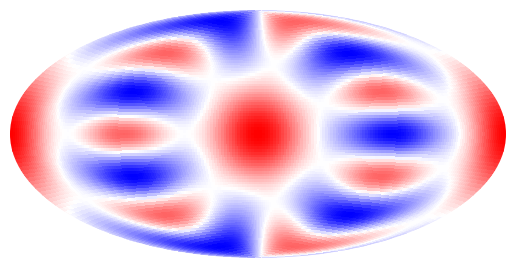

In [28]:
tomo_plot_hammer(Upulse*U0*psi, 'w')

In [77]:
qudit_linear_entropy(psi_list[1], S)

0.5

In [40]:
qudit_linear_entropy(Upulse*U0*psi,S)

0.5

In [5]:
def kicked_dynamics(psi_initial, tau, kappa, j, N = 1):
    # Spin is 7/2 => dimension is 8
    S = j
    dim = int(2*S + 1)

    # Number of pulses


    # Parameters
    chi = kappa/2

    # QuTiP spin operators
    Jx = spin_Jx(S)
    Jy = spin_Jy(S)
    Jz = spin_Jz(S)

    # Free Hamiltonian H0
    H0 = (np.pi/(2)) * Jx

    # Precompute the free evolution operator for time tau
    U0 = (-1j * H0 * tau).expm()

    # Larmor pulse unitary (instantaneous)
    Ularmor = (-1j * chi * (Jz)).expm()

    # Precompute the pulse unitary (instantaneous)
    Upulse = (-1j * (kappa/(2.0 * S)) * (Jz**2)).expm()

    


    # Evolve the state stroboscopically
    psi = psi_initial          # Start with the prepared state
    psi_list = [psi]           # Store states after each pulse
    overlap_list = [psi.overlap(psi_initial)]  # Overlap with the initial state
    entropy_list  = [qudit_linear_entropy(psi, j)]
    exp_list = [qudit_exp(psi, j)]

    for n in range(N):
        # 1) Free evolution for time tau
        psi = U0 * psi

        # 2) Instantaneous pulse
        psi = Upulse * psi
        # psi = Ularmor * psi

        # Store the new state and its overlap with the initial state
        psi_list.append(psi)
        overlap_list.append(psi.overlap(psi_initial))
        entropy_list.append(qudit_linear_entropy(psi, j))
        exp_list.append(qudit_exp(psi, j))

    return psi_list, overlap_list, entropy_list

# Entropy calculation

In [6]:
j=7/2
Ix = jmat(j,'x')
Iy = jmat(j,'y')
Iz = jmat(j,'z')

In [7]:
psi = basis(8, 0)
expect(Iz, psi)

3.5

In [8]:
def qudit_linear_entropy(psi, j):
    Ix = jmat(j,'x')
    Iy = jmat(j,'y')
    Iz = jmat(j,'z')
    entropy = 1/2*(1 - (expect(Ix, psi)**2 + expect(Iy, psi)**2 + expect(Iz, psi)**2)/(j)**2)
    return entropy

In [9]:
def qudit_exp(psi, j):
    Ix = jmat(j,'x')
    Iy = jmat(j,'y')
    Iz = jmat(j,'z')
    exp_x = expect(Ix, psi)
    exp_y = expect(Iy, psi)
    exp_z = expect(Iz, psi)
    exp_array = [exp_x, exp_y, exp_z]
    return exp_array

In [10]:
def initial_state(theta, phi, j):
    dim = int(2*j + 1)
    
    psi0 = basis(dim, 0)
    psi_normal = Displace(theta, phi, psi0, j)

    return psi_normal

In [11]:
def sample_initial_states(n_points):
    initial_state_list = []
    
    phis = np.linspace(-np.pi, np.pi, 2 * n_points)
    thetas = np.linspace(0, np.pi, n_points)

    for theta in thetas:
        for phi in phis:
            state = initial_state(theta, phi)
            initial_state_list.append(state)
    
    return initial_state_list

In [12]:
def analyze_entropy_distribution(num_theta, num_phi, tau, kappa, j, N):
    import numpy as np
    import matplotlib.pyplot as plt
    from scipy.interpolate import griddata

    # Step 1: Generate initial states with all (theta, phi) combinations
    initial_states_with_coords = []
    thetas = np.linspace(0, np.pi, num_theta)
    phis = np.linspace(-np.pi, np.pi, num_phi)

    for theta in thetas:
        for phi in phis:
            state = initial_state(theta, phi, j)
            initial_states_with_coords.append((theta, phi, state))

    # Step 2: Time evolve and extract final entropies
    entropies = []
    theta_vals = []
    phi_vals = []
    exp_list = []

    for theta, phi, state in initial_states_with_coords:
        state_t, _, entropy_t = kicked_dynamics(state, tau, kappa, j, N)
        final_entropy = entropy_t[-1]  # Or use np.mean(entropy_t[-20:]) if averaging preferred

        entropies.append(final_entropy)

        theta_vals.append(theta)
        phi_vals.append(phi)
        

    # Step 3: Convert to 2D grid for plotting
    theta_vals = np.array(theta_vals)
    phi_vals = np.array(phi_vals)
    entropies = np.array(entropies)

    grid_theta, grid_phi = np.meshgrid(thetas, phis)
    grid_entropy = griddata(
        (theta_vals, phi_vals),
        entropies,
        (grid_theta, grid_phi),
        method='cubic'
    )

    # Step 4: Plot
    plt.figure(figsize=(8, 6))
    im = plt.pcolormesh(grid_phi, grid_theta, grid_entropy, shading='auto', cmap='bwr')
    # plt.xlabel("Phi (φ) [-π, 0]")
    # plt.ylabel("Theta (θ) [0, π/2]")
    plt.title(f'Quantum Phase Space — κ={kappa:.2f}, τ={tau:.2f}')
    plt.colorbar(im, label='Entropy')
    plt.show()

    return entropies, 


In [13]:
# Step 1: Generate initial states with all (theta, phi) combinations
from scipy.interpolate import griddata
num_theta = 30
num_phi = 60
tau = 1
N = 1
initial_states_with_coords = []
thetas = np.linspace(0, np.pi, num_theta)
phis = np.linspace(-np.pi, np.pi, num_phi)

for theta in thetas:
    for phi in phis:
        state = initial_state(theta, phi, j)
        initial_states_with_coords.append((theta, phi, state))

# Step 2: Time evolve and extract final entropies
entropies = []
theta_vals = []
phi_vals = []
exp_list = []

for theta, phi, state in initial_states_with_coords:
    state_t, _, entropy_t = kicked_dynamics(state, tau, kappa, j, N)
    final_entropy = entropy_t[-1]  # Or use np.mean(entropy_t[-20:]) if averaging preferred

    entropies.append(final_entropy)

    theta_vals.append(theta)
    phi_vals.append(phi)


# Step 3: Convert to 2D grid for plotting
theta_vals = np.array(theta_vals)
phi_vals = np.array(phi_vals)
entropies = np.array(entropies)

grid_theta, grid_phi = np.meshgrid(thetas, phis)
grid_entropy = griddata(
    (theta_vals, phi_vals),
    entropies,
    (grid_theta, grid_phi),
    method='cubic'
)

NameError: name 'kappa' is not defined

In [ ]:
entropies_n = np.array([entropies_1[0], entropies_2[0], entropies_3[0], entropies_4[0]])
entropy_mean = np.mean(entropies_n, axis = 0)
entrop_reshaped = entropy_mean.reshape(30, 60)

In [ ]:
plt.figure(figsize=(8, 6))
im = plt.pcolormesh(entrop_reshaped, shading='auto', cmap='bwr')
# plt.xlabel("Phi (φ) [-π, 0]")
# plt.ylabel("Theta (θ) [0, π/2]")
plt.title(f'Quantum Phase Space — κ={kappa:.2f}, τ={tau:.2f}')
plt.colorbar(im, label='Entropy')
plt.show()

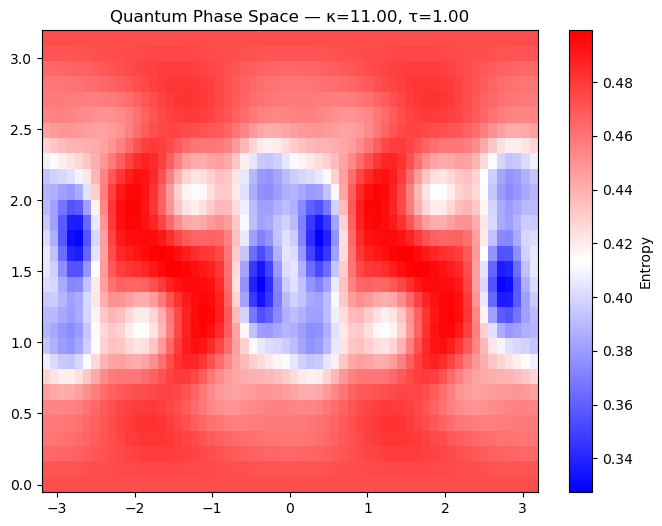

In [14]:
entropies_1 = analyze_entropy_distribution(num_theta=30, num_phi=60, tau=1, kappa=3.5*np.pi, j=5, N = 3)

In [ ]:
entropies_2 = analyze_entropy_distribution(num_theta=30, num_phi=60, tau=1, kappa=3.5*np.pi, j=5, N = 2)

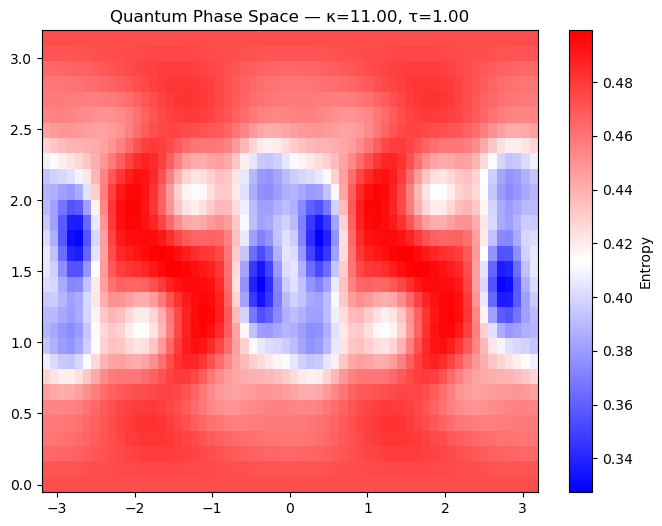

In [238]:
entropies_3 = analyze_entropy_distribution(num_theta=30, num_phi=60, tau=1, kappa=3.5*np.pi, j=5, N = 3)

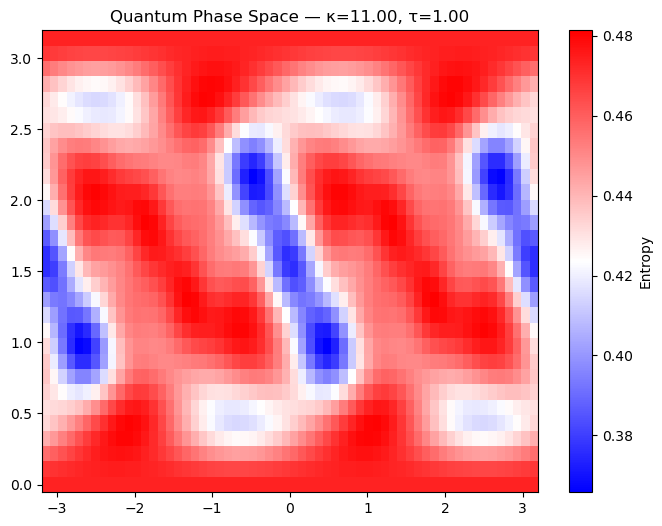

In [239]:
entropies_4 = analyze_entropy_distribution(num_theta=30, num_phi=60, tau=1, kappa=3.5*np.pi, j=5, N = 4)

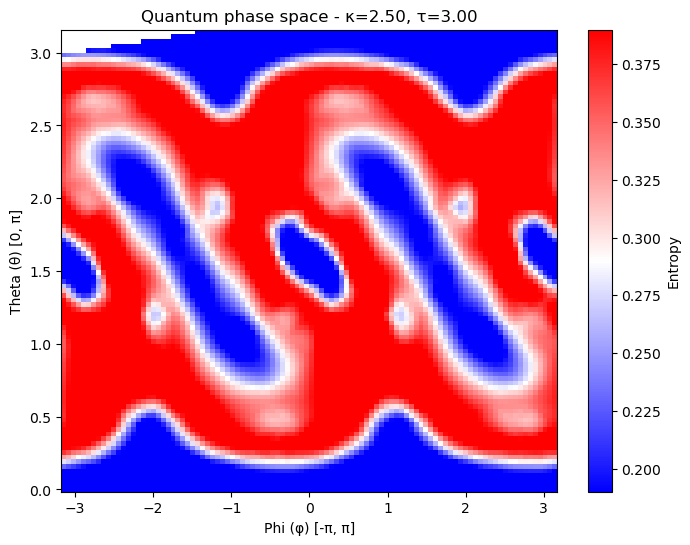

In [9]:
entropies = analyze_entropy_distribution(500, 3, 2.5, 40)

In [10]:
#tau_values = [1 * i for i in range(1, 4)]  # From 0.5 to 1.5 in steps of 0.1
tau_values = [1, 1.5, 2, 2.5, 3]
tau_values = np.round(tau_values, 2)
kappa_values = [0.5 * i for i in range(3, 6)]  # From 0 to 4.5 in steps of 0.5
#kappa_values = [0.5, 1.5]
kappa_values = np.round(kappa_values, 2)

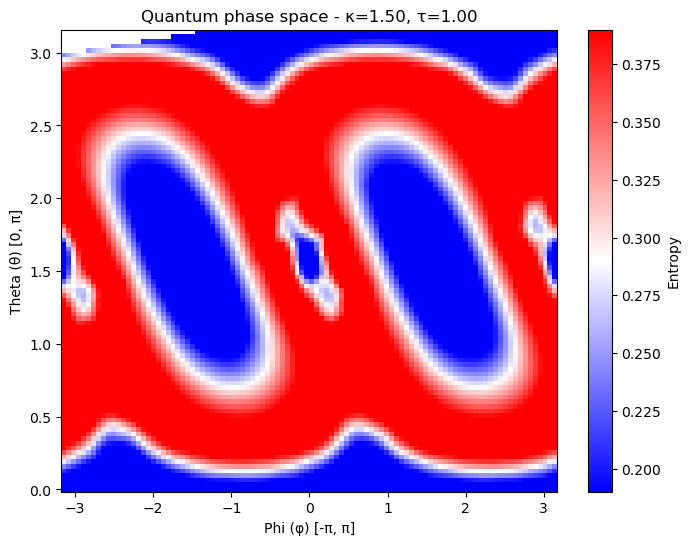

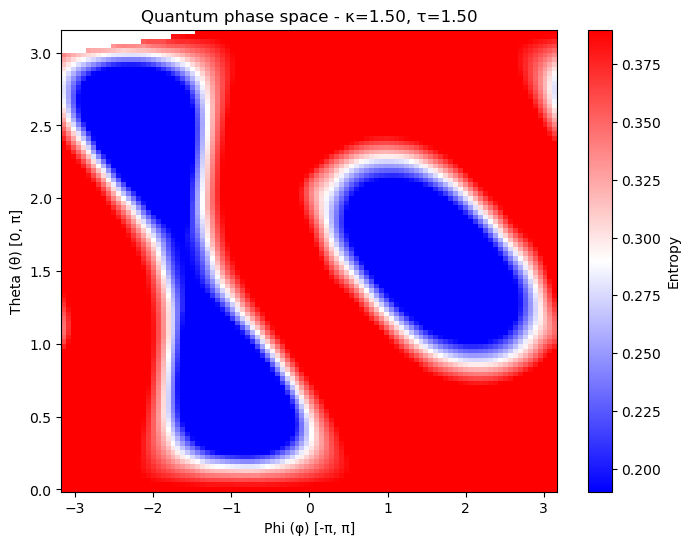

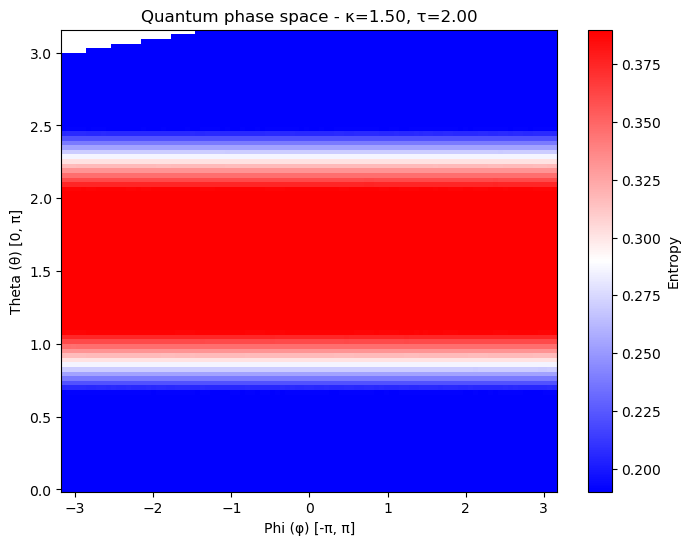

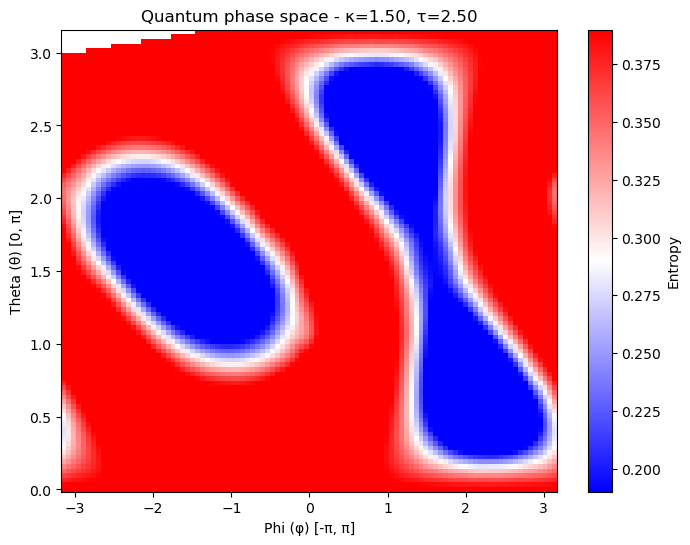

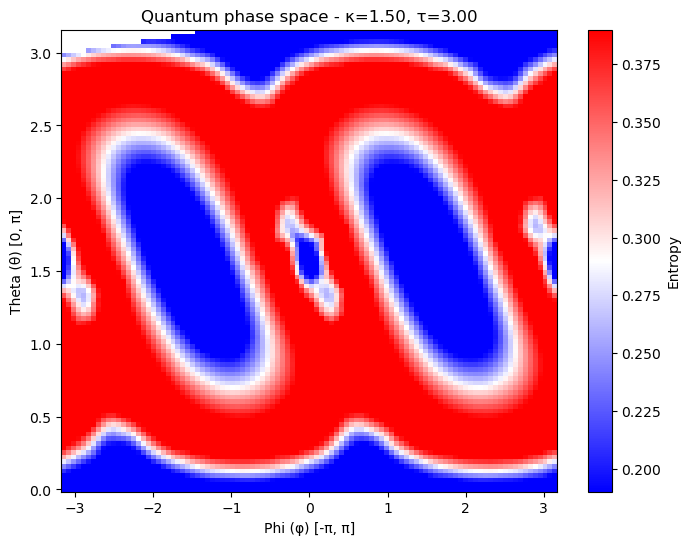

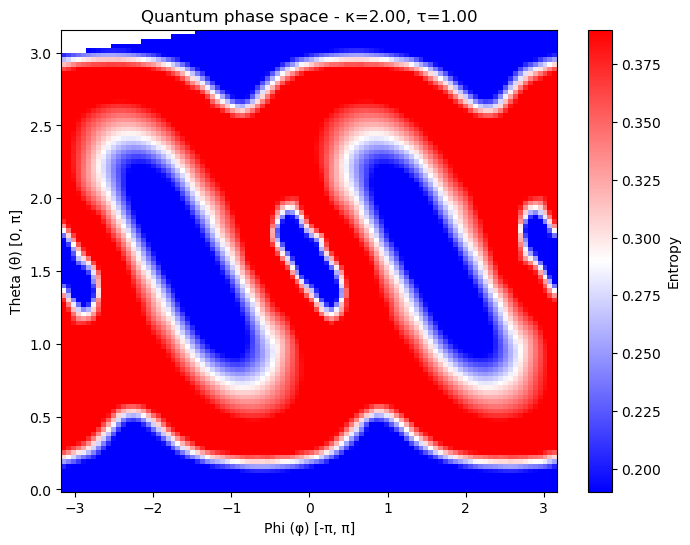

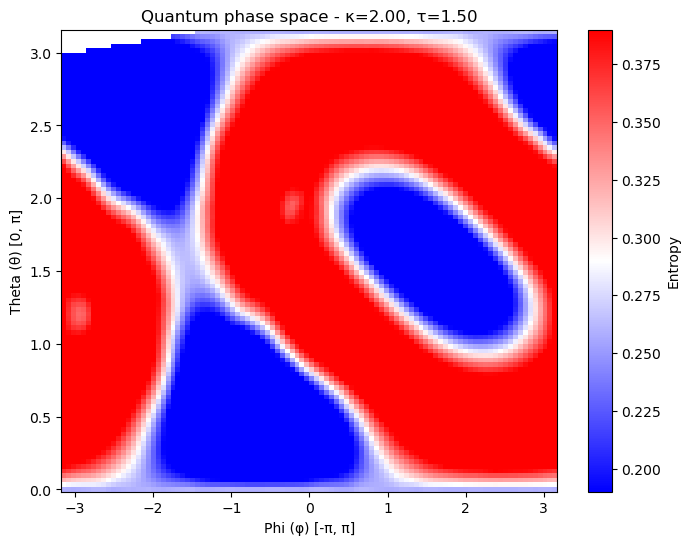

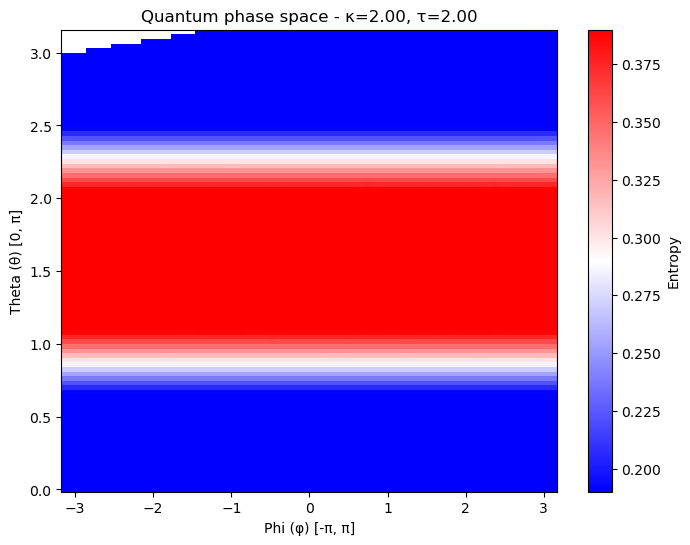

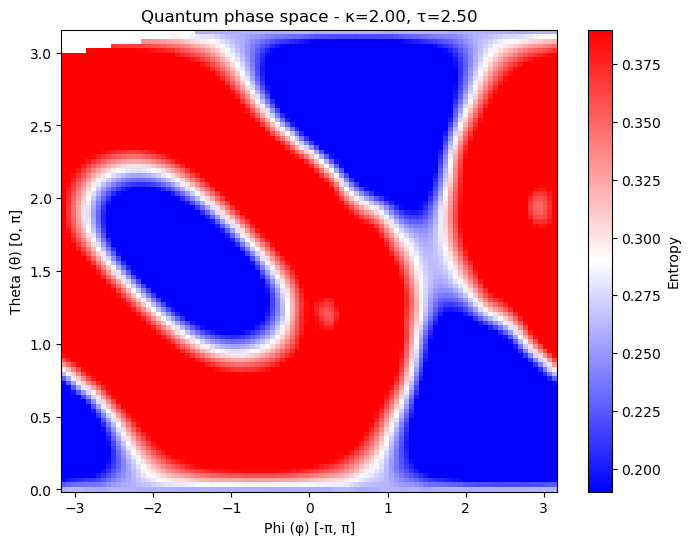

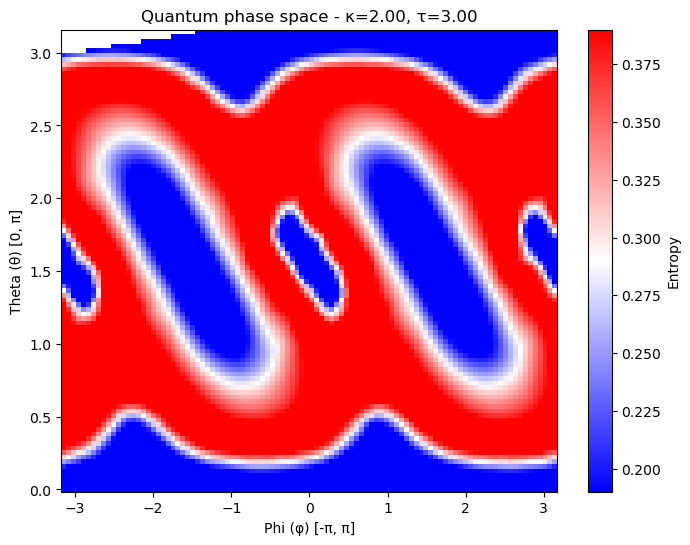

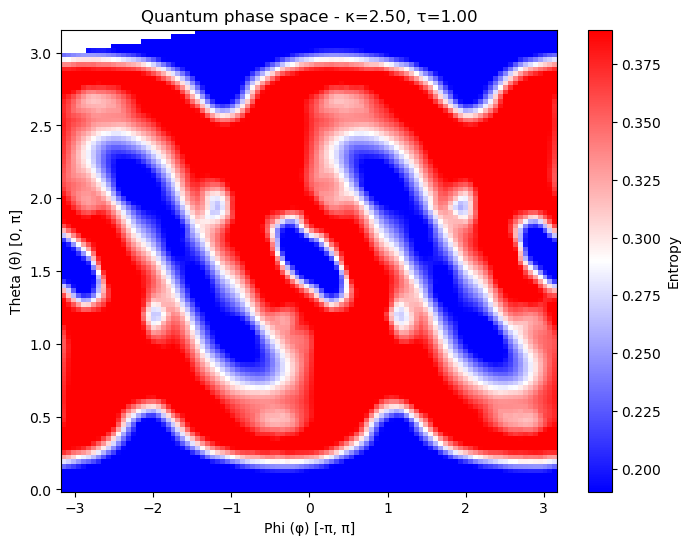

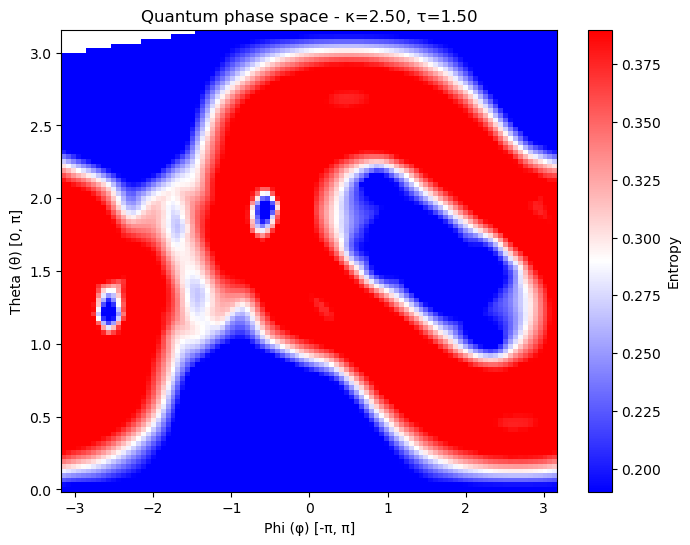

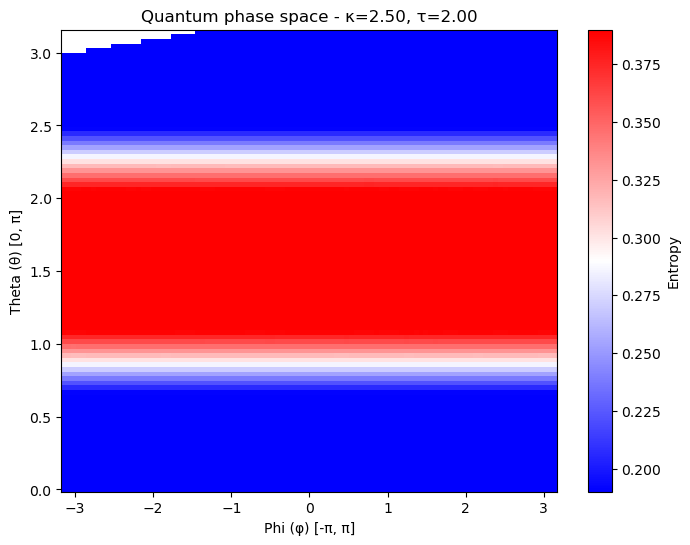

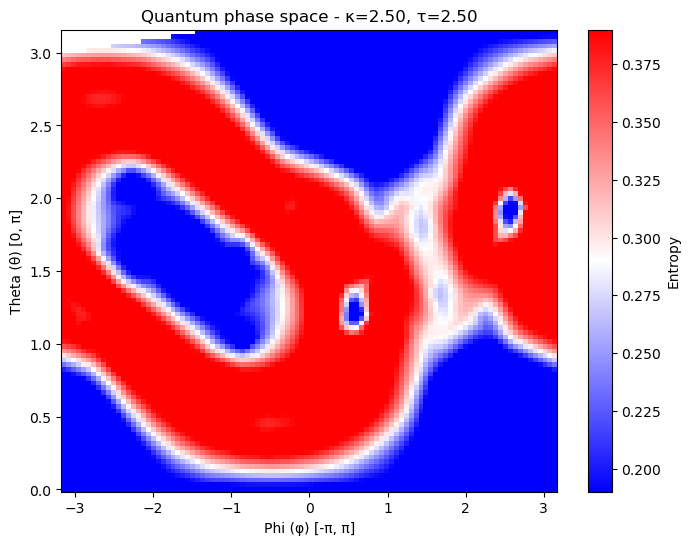

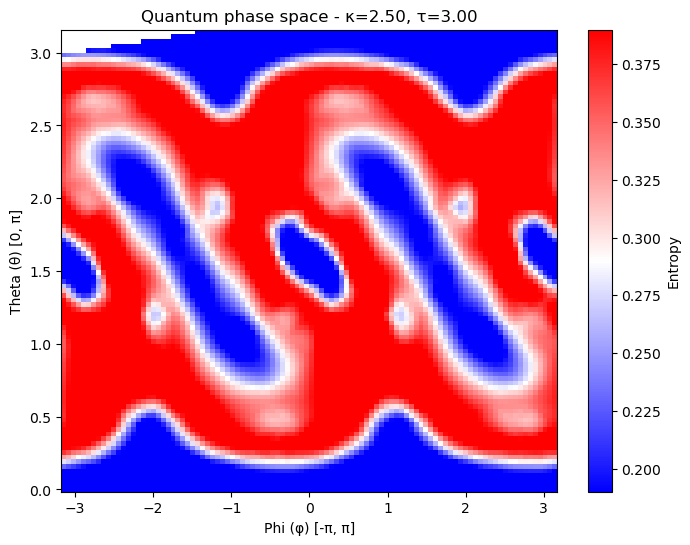

In [11]:
j = 40

for kappa in kappa_values:
    for tau in tau_values:
        analyze_entropy_distribution(500, tau, kappa, j)

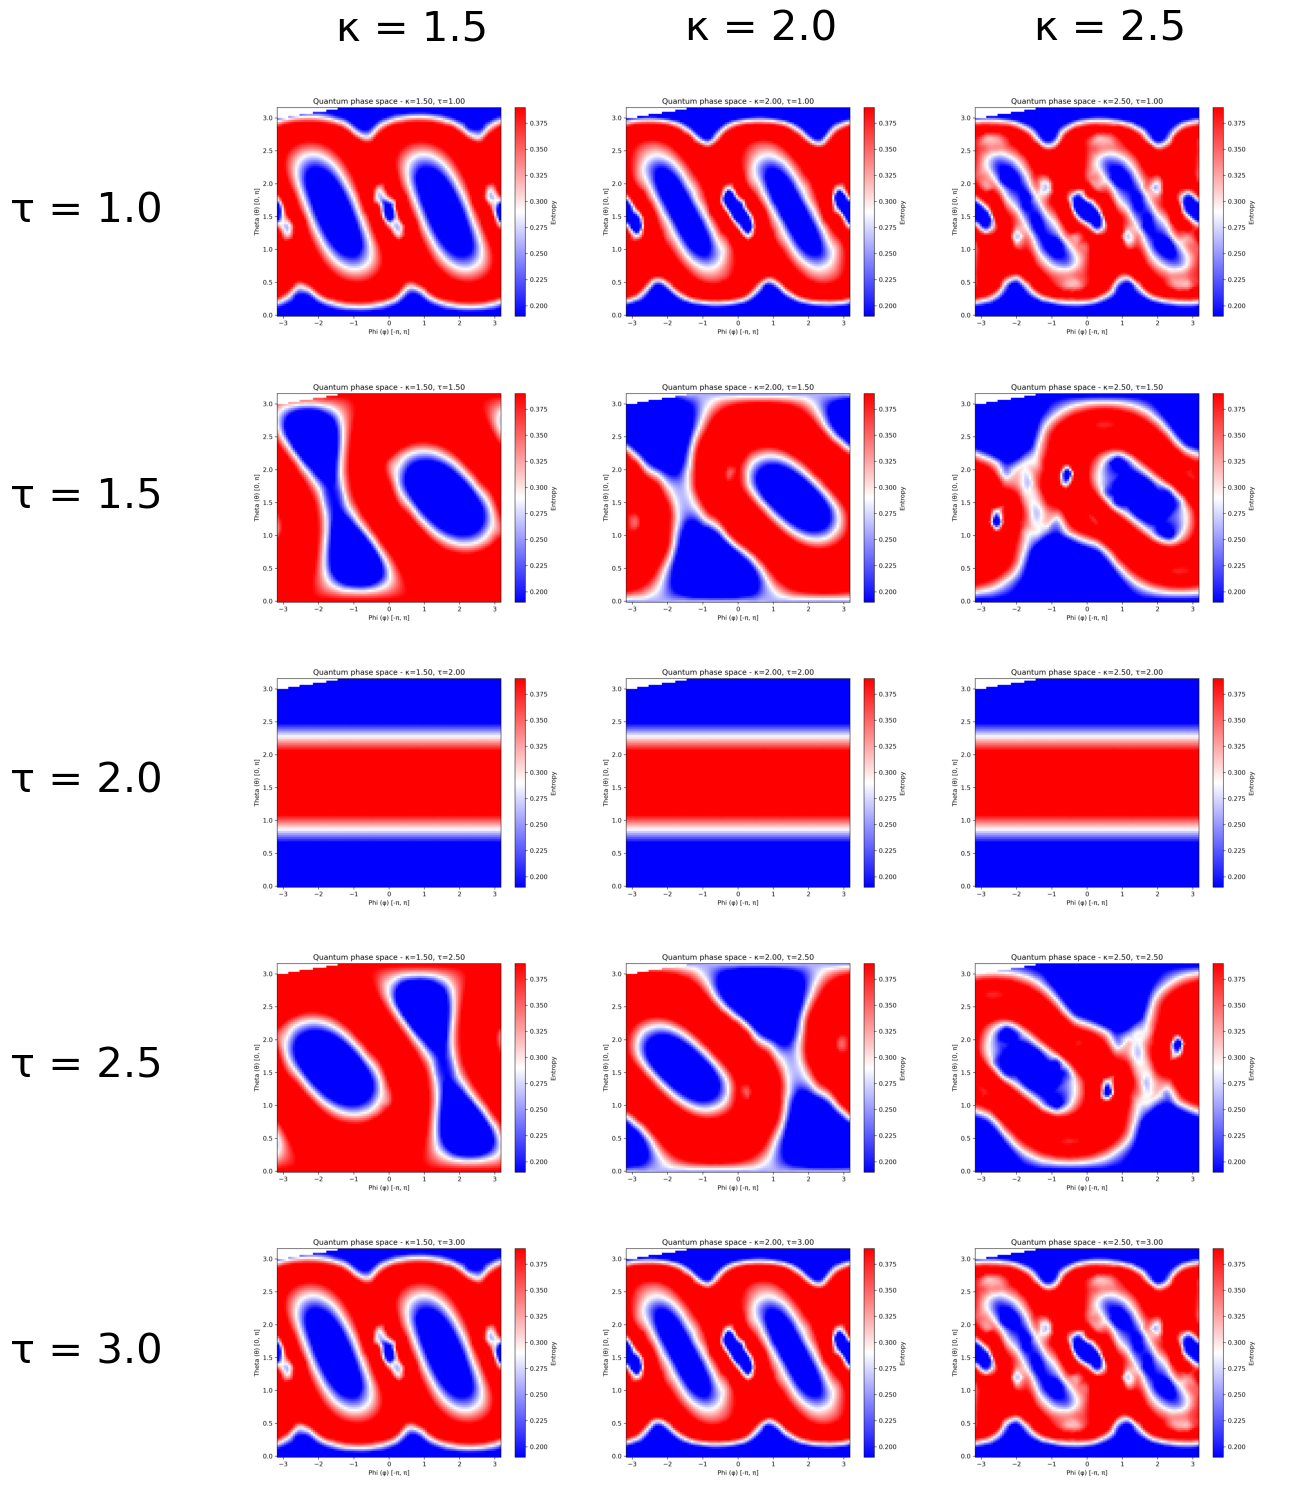

In [12]:
import matplotlib.image as mpimg

fig, axes = plt.subplots(len(tau_values), len(kappa_values), figsize=(13, 15))

# Loop over tau (rows) and kappa (columns)
for i, tau in enumerate(tau_values):
    for j, kappa in enumerate(kappa_values):
        filename = f"kappa_{kappa:.2f}_tau_{tau:.2f}.png"
        try:
            img = mpimg.imread(filename)
            ax = axes[i, j]
            ax.imshow(img)
            ax.axis('off')
            # Optional: Add labels on edge subplots
            if j == 0:
                ax.set_ylabel(f"τ = {tau:.1f}", fontsize=10)
            if i == len(tau_values) - 1:
                ax.set_xlabel(f"κ = {kappa:.1f}", fontsize=10)
        except FileNotFoundError:
            print(f"Missing file: {filename}")
            axes[i, j].axis('off')

# Add row labels (tau) on the left
for ax, tau in zip(axes[:, 0], tau_values):
    ax.annotate(
        f"τ = {tau}",
        xy=(0, 0.5),
        xytext=(-50, 0),  # Offset for label placement
        xycoords="axes fraction",
        textcoords="offset points",
        va="center",
        ha="right",
        fontsize=30
    )

# Add column labels (kappa) on top
for ax, kappa in zip(axes[0, :], kappa_values):
    ax.set_title(f"κ = {kappa}", y=1.1, fontsize=30)  # Adjust y-position

plt.tight_layout()
plt.savefig("combined_colormaps.png", dpi=300)
plt.show()